Ce notebook traite des points suivants:

1. Chargement de la grille temporelle traitée
2. Entraînement par validation croisée avec GroupKFold
3. Recherche de seuil dans toutes les zones de sécurité
4. (Facultatif) Optimisation des hyperparamètres avec Optuna
5. Entraînement et sauvegarde du modèle final
6. Évaluation sur l’ensemble de test

In [11]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from config.config import (
    FEATURE_COLUMNS, SAFETY_ZONES_KM, RISK_THRESHOLD,
    XGB_DEFAULT_PARAMS, HORIZON_MIN, CONFIRMATION_WINDOW, AIRPORT_MAPPING
)

from src.training.model import (
    train_with_cross_validation, smooth_probabilities, train_final_model
)
from src.training.tuning import (
    build_objective_maximize_gain, run_optuna
)
from src.evaluation.metrics import (
    compute_alert_masks, find_best_threshold,
    print_evaluation_report, apply_irrevocable_decision, compute_gain
)

from src.evaluation.report import (
    print_detailed_report,
    get_stats_filtered_by_airports,
    plot_probability_curve,
)

from src.pipeline.predict import save_model, load_model, predict_batch

from config.config import CONFIRMATION_WINDOW

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Chargement et préparation des données

In [12]:
#Chargement et préparation

df_train = pd.read_parquet('../data/grid_train.parquet')
df_test  = pd.read_parquet('../data/grid_test.parquet')

# La cible : danger dans les 30 min, zone 20km
TARGET_COL = f'target_{HORIZON_MIN}m_20km'

features    = [c for c in FEATURE_COLUMNS if c in df_train.columns]
X_all       = df_train[features]
y_all       = df_train[TARGET_COL]
groups_all  = df_train['storm_group_id']

print(f"Dataset: {len(df_train):,} lignes | {groups_all.nunique()} orages")
print(f"Équilibre des classes ({TARGET_COL}) : {y_all.mean():.2%} positif")

Dataset: 209,254 lignes | 2627 orages
Équilibre des classes (target_30m_20km) : 56.58% positif


## 2. Entraînement par validation croisée avec GroupKFold

In [13]:
oof_preds, fold_models = train_with_cross_validation(
    X_all, y_all, groups_all, params=XGB_DEFAULT_PARAMS,
    n_splits=2
)

df_train['proba_brute']  = oof_preds
df_train['proba_lissee'] = smooth_probabilities(df_train, raw_proba_col='proba_brute')

  Pli 1/2...
  Pli 2/2...
Validation croisée terminée.


## 3. Recherche de seuil dans toutes les zones de sécurité

In [14]:
print(df_train.columns.tolist())

['date', 'airport_id', 'storm_group_id', 'minutes_since_last_strike', 'cum_n_strikes', 'activity_count_last_5m', 'dist_last_5m', 'delta_dist_last_5m', 'abs_amplitude_last_5m', 'activity_count_last_20m', 'dist_last_20m', 'distance_macro_trend', 'activity_drop_ratio', 'vitesse_eloignement', 'dist_projetee_30m', 'dist_centroid_actuel', 'dist_centroid_proj_30m', 'centroid_eloignement_net', 'count_ic_last_20m', 'count_cg_last_20m', 'count_pos_last_20m', 'ratio_ic_cg_last_20m', 'ratio_pos_last_20m', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'azimuth_std_last_5m', 'storm_spread_radial', 'energie_last_5m', 'energy_drop_ratio', 'last_known_dist', 'target_30m_3km', 'target_30m_5km', 'target_30m_7km', 'target_30m_10km', 'target_30m_15km', 'target_30m_20km', 'count_cg_3km', 'count_cg_5km', 'count_cg_7km', 'count_cg_10km', 'count_cg_15km', 'count_cg_20km', 'proba_brute', 'proba_lissee']


In [15]:
results = find_best_threshold(
    df_train,
    safety_zones_km= SAFETY_ZONES_KM,
    risk_threshold=RISK_THRESHOLD,
    confirmation_window=CONFIRMATION_WINDOW,
    horizon_min=HORIZON_MIN,
)

In [16]:
for zone_km in SAFETY_ZONES_KM:
    print_detailed_report(
        results=results,
        zone_km=zone_km,
        training_threshold=0.50,
        airports=None
    )


  📊 RAPPORT DÉTAILLÉ — Zone d'audit : 3 km

  ⚙️  CONFIGURATION
  ----------------------------------------------------------------------------
  • Seuil d'entraînement        :  50.000%
  • Seuil de test               :  55.408%
  • Aéroports                    : Tous

  📈 RÉSULTATS GLOBAUX
  ----------------------------------------------------------------------------
  • Gain total                  :   45518 minutes
  • Risque R                    :   1.995%

  📉 STATISTIQUES PAR ORAGE
  ----------------------------------------------------------------------------
  • Gain moyen                  :    17.3 minutes
  • Gain médian                 :    16.0 minutes
  • Écart-type                  :    11.9 minutes
  • Gain minimum                :     0.0 minutes
  • Gain maximum                :   211.0 minutes
  • Q25 (1er quartile)          :    14.0 minutes
  • Q75 (3e quartile)           :    18.0 minutes



  📊 RAPPORT DÉTAILLÉ — Zone d'audit : 5 km

  ⚙️  CONFIGURATION
  ---------

## 4. Optimisation des hyperparamètres avec Optuna (facultatif, déjà de bons résultats avec les paramètres par défaut)

In [17]:
RUN_OPTUNA = False

if RUN_OPTUNA:
    objective = build_objective_maximize_gain(X_all, y_all, groups_all, df_train)
    study = run_optuna(
        objective,
        n_trials=10,
        best_known_params=XGB_DEFAULT_PARAMS,
    )
    print('Best params:', study.best_params)

## 5. Entraînement du modèle final sur l’ensemble des données d’entraînement

In [18]:
model_final = train_final_model(X_all, y_all, params=XGB_DEFAULT_PARAMS)
save_model(model_final, '../models/xgb_final.pkl')

Entraînement du modèle final sur 100% des données...
Modèle final prêt.
Modèle sauvegardé dans ../models/xgb_final.pkl


## 6. Importance des features

                  Feature  Importance
      activity_drop_ratio    0.441201
minutes_since_last_strike    0.171331
          last_known_dist    0.068821
   activity_count_last_5m    0.059411
     ratio_ic_cg_last_20m    0.025624
     dist_centroid_actuel    0.022326
             dist_last_5m    0.020219
        count_ic_last_20m    0.017842
            cum_n_strikes    0.016986
  activity_count_last_20m    0.016498
    abs_amplitude_last_5m    0.015641
        count_cg_last_20m    0.015139
   dist_centroid_proj_30m    0.009937
                month_cos    0.008992
            dist_last_20m    0.008802


/tmp/ipykernel_46987/432176608.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=df_importance.head(20), palette='viridis')


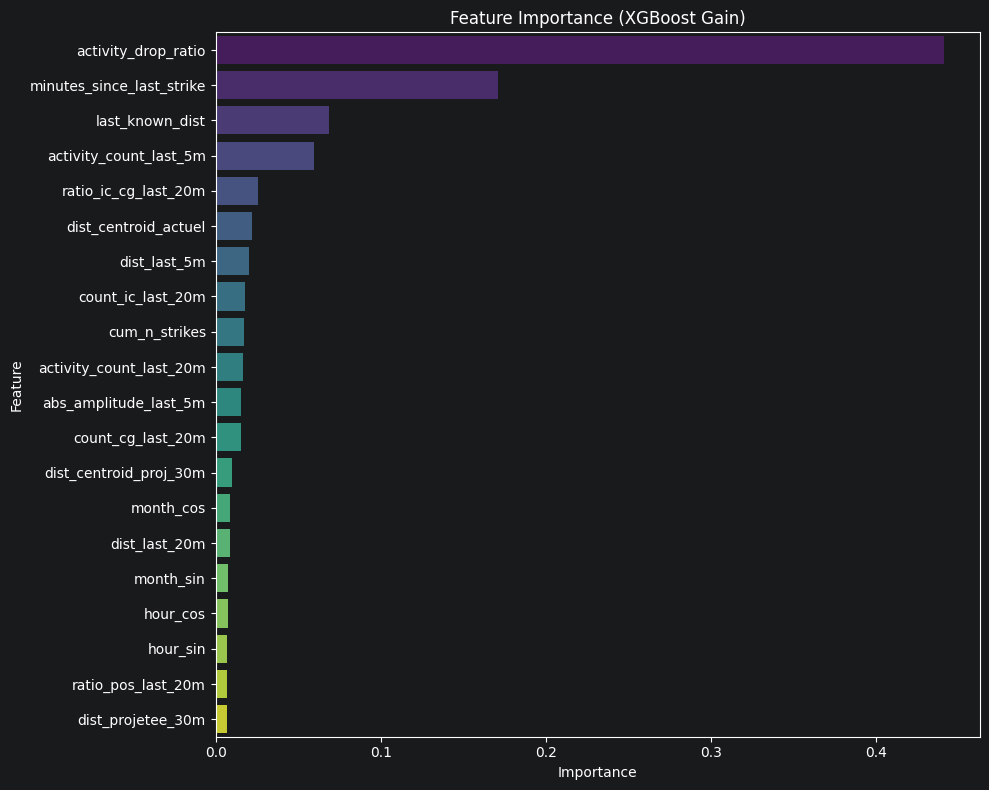

In [19]:
import pandas as pd

df_importance = pd.DataFrame({
    'Feature': features,
    'Importance': model_final.feature_importances_
}).sort_values('Importance', ascending=False)

print(df_importance.head(15).to_string(index=False))

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=df_importance.head(20), palette='viridis')
plt.title('Feature Importance (XGBoost Gain)')
plt.tight_layout()
plt.show()

## 7. Evaluation sur l’ensemble de test

In [20]:
results_test = predict_batch(
    model_final,
    df_test,
    safety_zones_km=SAFETY_ZONES_KM,
    risk_threshold=RISK_THRESHOLD,
)

# Afficher les rapports détaillés pour test
print("\n" + "="*80)
print("🧪 RÉSULTATS SUR L'ENSEMBLE DE TEST")
print("="*80)
for zone_km in SAFETY_ZONES_KM:
    print_detailed_report(
        results=results_test,
        zone_km=zone_km,
        airports=None
    )

Données brutes détectées. Construction de la grille temporelle...
Construction de la grille temporelle (horizon=30m, zones=[3, 5, 7, 10, 15, 20]km)...
Assemblage de la grille finale...

Zone (km)          Seuil    Gain (min)  Risque (%)
---------------------------------------------------------------------------
3                23.943%         11937      1.558%
5                59.669%         20164      1.944%
7                53.769%         19234      1.944%
10               59.669%         20164      1.938%
15               53.441%         19156      1.965%
20               52.786%         19023      1.988%

🧪 RÉSULTATS SUR L'ENSEMBLE DE TEST

  📊 RAPPORT DÉTAILLÉ — Zone d'audit : 3 km

  ⚙️  CONFIGURATION
  ----------------------------------------------------------------------------
  • Seuil de test               :  23.943%
  • Aéroports                    : Tous

  📈 RÉSULTATS GLOBAUX
  ----------------------------------------------------------------------------
  • Gain total  

## 8. Visualisation d'une courbe de probabilité pour un orage

🌩️  Orages avec éclairs trouvés : [1276, 330, 839]


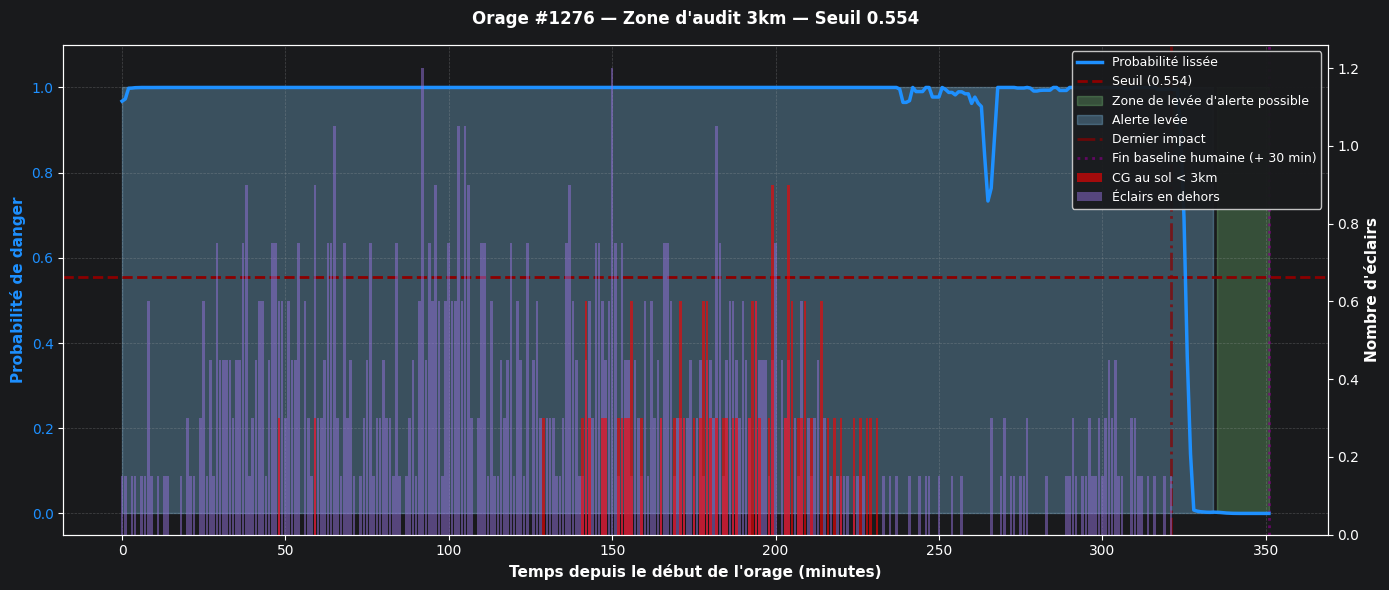

In [21]:

# Trouver quelques orages avec suffisamment d'éclairs
storms_with_strikes = (
    df_train.groupby('storm_group_id')['count_cg_3km'].sum()
    [lambda x: x > 0]
    .nlargest(3)
    .index.tolist()
)

print(f"🌩️  Orages avec éclairs trouvés : {storms_with_strikes}")

# Visualiser le premier orage
if storms_with_strikes:
    best_threshold_3km = results[3]['threshold']

    plot_probability_curve(
        df=df_train,
        storm_id=storms_with_strikes[0],
        threshold=best_threshold_3km,
        safety_zone_km=3,
        confirmation_window=CONFIRMATION_WINDOW,
        horizon_min=HORIZON_MIN,
    )